In [24]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import (
    accuracy_score , precision_score , recall_score , f1_score , roc_auc_score , classification_report , confusion_matrix , ConfusionMatrixDisplay
) 

x_train = pd.read_csv("../data/processed/x_train.csv")
x_test = pd.read_csv("../data/processed/x_test.csv") 
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel() 

print(f'x_train Shape : {x_train.shape}') 
print(f'x_test Shape : {x_test.shape}')  

x_train Shape : (5634, 30)
x_test Shape : (1409, 30)


In [25]:
def evaluate_model (model_name , y_true , y_pred , y_proba) : 
    metrics = {
        "Model" : model_name,
        "Accuracy" : accuracy_score(y_true , y_pred),
        "Precision" : precision_score(y_true , y_pred),
        "Recall" : recall_score(y_true , y_pred),
        "F1-Score" : f1_score(y_true , y_pred),
        "ROC-AUC" : roc_auc_score(y_true , y_proba)
    } 

    print(f'--- {model_name} ---') 
    for metric , value in metrics.items() : 
        if metric != 'Model' : 
            print(f'{metric} : {value:.4f}') 

    return metrics 

## Train Baseline Logistic Regression 

In [26]:
log_reg = LogisticRegression(max_iter = 1000 , class_weight = 'balanced' , random_state = 42) 
log_reg.fit(x_train , y_train) 

# Make Predictions on test set 
y_pred = log_reg.predict(x_test) 
y_pred_proba = log_reg.predict_proba(x_test)[: , 1]  

In [27]:
lr_results = evaluate_model("Logistic Regression Baseline" , y_test , y_pred , y_pred_proba) 

print('\nDetailed Classification Report : ') 
print(classification_report(y_test , y_pred)) 

--- Logistic Regression Baseline ---
Accuracy : 0.7381
Precision : 0.5043
Recall : 0.7834
F1-Score : 0.6136
ROC-AUC : 0.8417

Detailed Classification Report : 
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



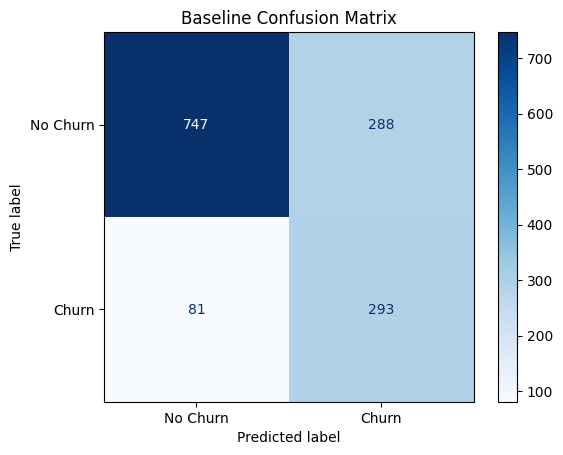

In [28]:
# Confusion Matrix 

cm = confusion_matrix(y_test , y_pred) 
disp = ConfusionMatrixDisplay(confusion_matrix = cm , display_labels = ['No Churn' , 'Churn']) 

disp.plot(cmap = 'Blues') 
plt.title('Baseline Confusion Matrix') 
plt.show() 

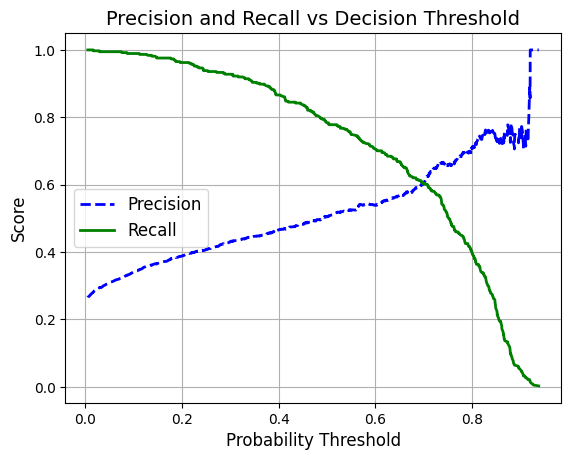

In [29]:
from sklearn.metrics import precision_recall_curve 

precisions , recalls , thresholds = precision_recall_curve(y_test , y_pred_proba) 

plt.plot(thresholds , precisions[:-1] , "b--" , label = "Precision" , linewidth = 2) 
plt.plot(thresholds , recalls[:-1] , "g-" , label = "Recall" , linewidth = 2) 
plt.xlabel("Probability Threshold" , fontsize = 12) 
plt.ylabel("Score" , fontsize = 12) 
plt.title("Precision and Recall vs Decision Threshold" , fontsize = 14) 
plt.legend(loc = "center left" , fontsize = 12) 
plt.grid(True) 
plt.show() 

## The Value of Score where Both the lines meet , that gives you a much better balance between catching churners and avoiding false alarms 

In [30]:
# Custom Threshold Predictions 

custom_threshold = 0.60 
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int) 

lr_tuned_results = evaluate_model("Logistic Regression (Threshold = 0.6)" , y_test , y_pred_custom , y_pred_proba) 

--- Logistic Regression (Threshold = 0.6) ---
Accuracy : 0.7622
Precision : 0.5399
Recall : 0.7059
F1-Score : 0.6118
ROC-AUC : 0.8417


> **Key Finding:** Raising the decision threshold to `0.60` successfully improved **Accuracy** and **Precision** by filtering out false alarms. However, this came with an expected trade-off: **Recall** dropped from `78.0%` to `70.6%`. 

## Random Forest Model 

In [31]:
from sklearn.ensemble import RandomForestClassifier 

rf_model = RandomForestClassifier(n_estimators = 100 , class_weight = 'balanced' , random_state = 42) 
rf_model.fit(x_train , y_train) 

y_pred_rf = rf_model.predict(x_test) 
y_pred_rf_proba = rf_model.predict_proba(x_test)[: , 1] 

rf_results = evaluate_model("Random Forest" , y_test , y_pred_rf , y_pred_rf_proba) 

--- Random Forest ---
Accuracy : 0.7913
Precision : 0.6389
Recall : 0.4920
F1-Score : 0.5559
ROC-AUC : 0.8237


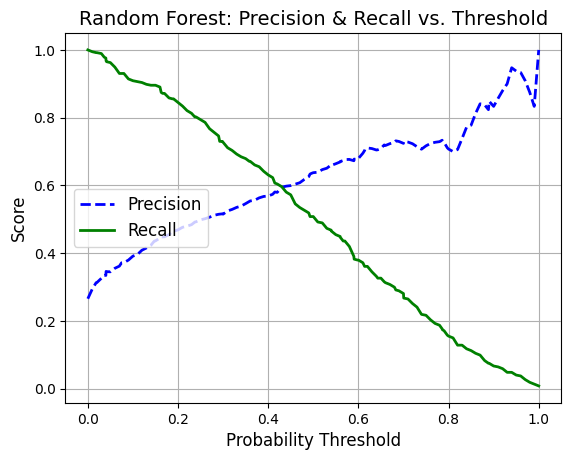

In [32]:
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall for Random Forest probabilities
precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(y_test, y_pred_rf_proba)

# Plot Precision and Recall vs Threshold for Random Forest
plt.plot(thresholds_rf, precisions_rf[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds_rf, recalls_rf[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Probability Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Random Forest: Precision & Recall vs. Threshold", fontsize=14)
plt.legend(loc="center left", fontsize=12)
plt.grid(True)
plt.show() 

In [33]:
# Comparison at both thresholds
for t in [0.38, 0.60]:
    y_pred_t = (y_pred_rf_proba >= t).astype(int) 

    rf_custom_thr_results = evaluate_model(f"Random Forest @ Threshold = {t}" , y_test , y_pred_t , y_pred_rf_proba) 
    print() 

--- Random Forest @ Threshold = 0.38 ---
Accuracy : 0.7736
Precision : 0.5632
Recall : 0.6551
F1-Score : 0.6057
ROC-AUC : 0.8237

--- Random Forest @ Threshold = 0.6 ---
Accuracy : 0.7878
Precision : 0.6794
Recall : 0.3797
F1-Score : 0.4871
ROC-AUC : 0.8237



In [34]:
from sklearn.model_selection import RandomizedSearchCV 

param_dist = {
    'n_estimators' : [100,200,300],
    'max_depth' : [4,6,8,10],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4],
    'max_features' : ['sqrt','log2'],
    'class_weight' : ['balanced','balanced_subsample']
} 

rf_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state = 42),
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
) 

rf_search.fit(x_train,y_train) 

best_rf = rf_search.best_estimator_ 
print('Best Parameters Found :', rf_search.best_params_) 

# Evaluate Tuned Model 
y_pred_best_rf = best_rf.predict(x_test) 
y_pred_best_rf_proba = best_rf.predict_proba(x_test)[:, 1] 

print()

tuned_rf_results = evaluate_model("Random Forest (Tuned)" , y_test , y_pred_best_rf , y_pred_best_rf_proba) 

Best Parameters Found : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}

--- Random Forest (Tuned) ---
Accuracy : 0.7637
Precision : 0.5380
Recall : 0.7754
F1-Score : 0.6353
ROC-AUC : 0.8445


In [36]:
from xgboost import XGBClassifier 

# Calculate imbalance ratio (Non-Churn count / Churn count)
ratio = (y_train == 0).sum() / (y_train == 1).sum() 

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth = 4,
    learning_rate = 0.05,
    scale_pos_weight = ratio,
    random_state = 42,
    eval_metric = 'logloss'
) 

xgb_model.fit(x_train, y_train) 

y_pred_xgb = xgb_model.predict(x_test) 
y_pred_xgb_proba = xgb_model.predict_proba(x_test)[:, 1]

xgb_results = evaluate_model("XGBoost" , y_test , y_pred_xgb , y_pred_xgb_proba) 

--- XGBoost ---
Accuracy : 0.7480
Precision : 0.5161
Recall : 0.8128
F1-Score : 0.6314
ROC-AUC : 0.8440


In [38]:
import pandas as pd 

results = pd.DataFrame([lr_tuned_results , tuned_rf_results , xgb_results])

results 

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Threshold = 0.6),0.762243,0.539877,0.705882,0.611819,0.841732
1,Random Forest (Tuned),0.763662,0.538033,0.775401,0.635268,0.844453
2,XGBoost,0.748048,0.516129,0.812834,0.631360,0.844004


## Model Comparison & Final Model Selection 

The three models show a clear trade-off between precision and recall. 

- **Logistic Regression** provides a strong baseline but has the lowest F1-Score.
- **XGBoost** achieves the highest recall (81.28 %), making it effective at identifying potential churners, but its precision and accuracy are lower.
- **Tuned Random Forest** achieves the highest F1-Score (63.52 %) and ROC-AUC (84.44 %), while maintaining strong recall (77.54 %).

### Final Model 

The **Tuned Random Forest** is selected as the final model because it provides the best overall balance between precision, recall, F1-Score, and ROC-AUC for this churn prediction problem. 

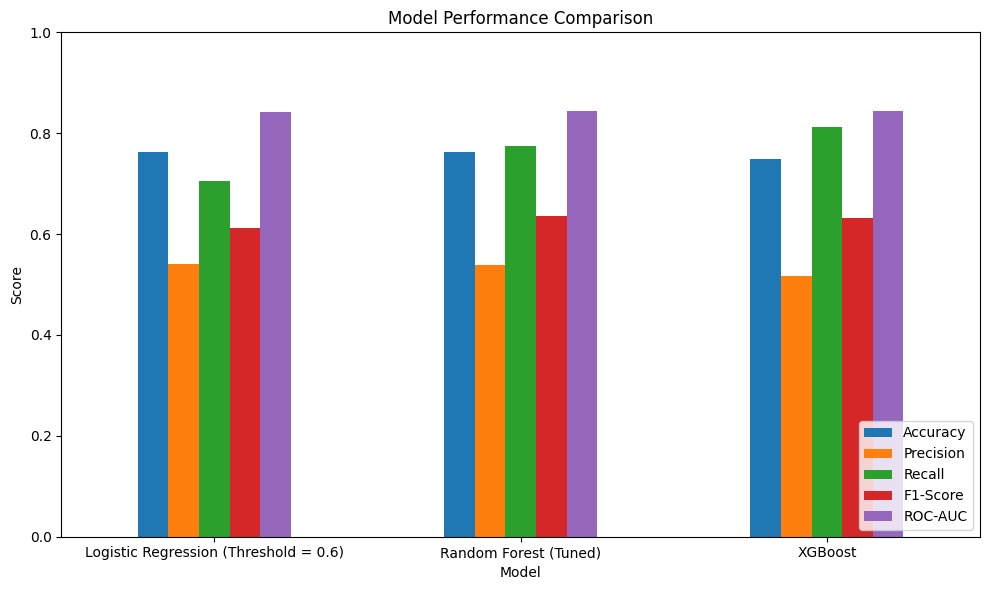

In [39]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(kind = 'bar', figsize = (10,6)) 

plt.title('Model Performance Comparison')
plt.ylabel('Score') 
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout() 
plt.show() 

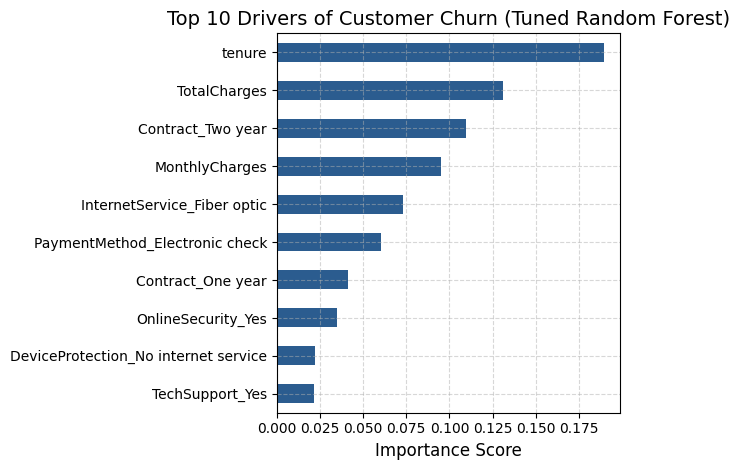

In [40]:
import pandas as pd 
import matplotlib.pyplot as plt 

feature_names = x_train.columns 

importances = pd.Series(best_rf.feature_importances_, index=feature_names) 

importances.nlargest(10).sort_values().plot(kind='barh', color='#2b5c8f')
plt.title('Top 10 Drivers of Customer Churn (Tuned Random Forest)', fontsize=14) 
plt.xlabel('Importance Score', fontsize=12) 
plt.grid(True, linestyle = '--', alpha=0.5)
plt.tight_layout() 
plt.show() 

In [41]:
import joblib

joblib.dump(best_rf, 'churn_tuned_rf_model.joblib')
print("Tuned Random Forest saved successfully!") 

Tuned Random Forest saved successfully!


In [42]:
print(x_test.shape)
print(best_rf.n_features_in_)

(1409, 30)
30


C:\Users\Ashutosh G Mehta\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


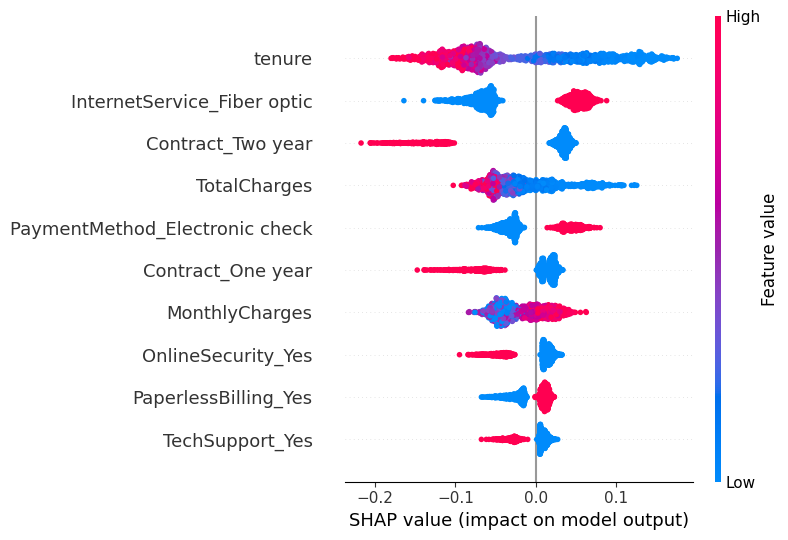

In [43]:
import shap 
import matplotlib.pyplot as plt 

explainer = shap.TreeExplainer(best_rf) 

shap_values = explainer.shap_values(x_test) 

shap.summary_plot(
    shap_values[:, :, 1],
    x_test,
    max_display = 10
) 